In [1]:
using Pkg
using Metal

cd(@__DIR__)
Pkg.activate("../")
ParamFile = "../config/testparam.csv"  # maybe GeoPoints and planet1D should be fusioned

# batchGPU should be at this level (I have not made it as a module yet, since the choice of Metal/CUDA should be done in a manual way)
include("../src/batchFiles/batchGPU.jl")


include("../src/commonBatchs.jl")
include("../src/planet1D.jl")
include("../src/GeoPoints.jl")

include("../src/flexOPT.jl")

using .commonBatchs, .planet1D, .GeoPoints, .flexOPT

  Activating 

devs = Metal.devices() = Metal.MTL.MTLDeviceInstance[Metal.MTL.MTLDeviceInstance (object of type AGXG13XDevice)]

project at `~/Documents/Github/flexOPT`



→ Using Metal backend (1 device(s))
Selected backend type: MetalBackend


# configurations (OPTnumerically)

In [2]:
nameConfigs = NamedTuple[]

push!(nameConfigs, (
    name = "convFD3",
    orderBtime = 1,
    orderBspace = -1,
    pointsInSpace = 3,
    pointsInTime = 1,
    supplementaryOrder = 0,
    fieldItpl = (
        ptsSpace = 1, ptsTime = 1,
        offsetSpace = 1.0, offsetTime = 1,
        YorderBspace = -1, YorderBtime = 1,
    ),
    materItpl = (
        ptsSpace = 1, ptsTime = 1,
        offsetSpace = 1.0, offsetTime = 1,
        YorderBspace = -1, YorderBtime = 1,
    ),
))

push!(nameConfigs, (
    name = "convFD5",
    orderBtime = 1,
    orderBspace = -1,
    pointsInSpace = 5,
    pointsInTime = 1,
    supplementaryOrder = 0,
    fieldItpl = (
        ptsSpace = 1, ptsTime = 1,
        offsetSpace = 2.0, offsetTime = 1,
        YorderBspace = -1, YorderBtime = 1,
    ),
    materItpl = (
        ptsSpace = 1, ptsTime = 1,
        offsetSpace = 2.0, offsetTime = 1,
        YorderBspace = -1, YorderBtime = 1,
    ),
))

push!(nameConfigs, (
    name = "convFD3_sup2",
    orderBtime = 1,
    orderBspace = -1,
    pointsInSpace = 3,
    pointsInTime = 1,
    supplementaryOrder = 2,
    fieldItpl = (
        ptsSpace = 1, ptsTime = 1,
        offsetSpace = 1.0, offsetTime = 1,
        YorderBspace = -1, YorderBtime = 1,
    ),
    materItpl = (
        ptsSpace = 1, ptsTime = 1,
        offsetSpace = 1.0, offsetTime = 1,
        YorderBspace = -1, YorderBtime = 1,
    ),
))

push!(nameConfigs, (
    name = "convFD5_sup2",
    orderBtime = 1,
    orderBspace = -1,
    pointsInSpace = 5,
    pointsInTime = 1,
    supplementaryOrder = 2,
    fieldItpl = (
        ptsSpace = 1, ptsTime = 1,
        offsetSpace = 2.0, offsetTime = 1,
        YorderBspace = -1, YorderBtime = 1,
    ),
    materItpl = (
        ptsSpace = 1, ptsTime = 1,
        offsetSpace = 2.0, offsetTime = 1,
        YorderBspace = -1, YorderBtime = 1,
    ),
))

push!(nameConfigs, (
    name = "OPT3",
    orderBtime = 1,
    orderBspace = 1,
    pointsInSpace = 3,
    pointsInTime = 1,
    supplementaryOrder = 2,
    fieldItpl = (
        ptsSpace = 1, ptsTime = 1,
        offsetSpace = 1.0, offsetTime = 1,
        YorderBspace = -1, YorderBtime = 1,
    ),
    materItpl = (
        ptsSpace = 1, ptsTime = 1,
        offsetSpace = 1.0, offsetTime = 1,
        YorderBspace = -1, YorderBtime = 1,
    ),
))

push!(nameConfigs, (
    name = "OPT3_lin",
    orderBtime = 1,
    orderBspace = 1,
    pointsInSpace = 3,
    pointsInTime = 1,
    supplementaryOrder = 2,
    fieldItpl = (
        ptsSpace = 3, ptsTime = 1,
        offsetSpace = 0.0, offsetTime = 1,
        YorderBspace = 1, YorderBtime = 1,
    ),
    materItpl = (
        ptsSpace = 3, ptsTime = 1,
        offsetSpace = 0.0, offsetTime = 1,
        YorderBspace = 1, YorderBtime = 1,
    ),
))

push!(nameConfigs, (
    name = "OPT3_lin_stag",
    orderBtime = 1,
    orderBspace = 1,
    pointsInSpace = 3,
    pointsInTime = 1,
    supplementaryOrder = 2,
    fieldItpl = (
        ptsSpace = 3, ptsTime = 1,
        offsetSpace = 0.0, offsetTime = 1,
        YorderBspace = 1, YorderBtime = 1,
    ),
    materItpl = (
        ptsSpace = 2, ptsTime = 1,
        offsetSpace = 0.5, offsetTime = 1,
        YorderBspace = 1, YorderBtime = 1,
    ),
))

push!(nameConfigs, (
    name = "OPT4",
    orderBtime = 1,
    orderBspace = 1,
    pointsInSpace = 4,
    pointsInTime = 1,
    supplementaryOrder = 2,
    fieldItpl = (
        ptsSpace = 1, ptsTime = 1,
        offsetSpace = 1.5, offsetTime = 1,
        YorderBspace = -1, YorderBtime = 1,
    ),
    materItpl = (
        ptsSpace = 1, ptsTime = 1,
        offsetSpace = 1.5, offsetTime = 1,
        YorderBspace = -1, YorderBtime = 1,
    ),
))

push!(nameConfigs, (
    name = "OPT4_lin",
    orderBtime = 1,
    orderBspace = 1,
    pointsInSpace = 4,
    pointsInTime = 1,
    supplementaryOrder = 2,
    fieldItpl = (
        ptsSpace = 3, ptsTime = 1,
        offsetSpace = 1.5, offsetTime = 1,
        YorderBspace = 1, YorderBtime = 1,
    ),
    materItpl = (
        ptsSpace = 3, ptsTime = 1,
        offsetSpace = 1.5, offsetTime = 1,
        YorderBspace = 1, YorderBtime = 1,
    ),
))

push!(nameConfigs, (
    name = "OPT4_lin_stag",
    orderBtime = 1,
    orderBspace = 1,
    pointsInSpace = 4,
    pointsInTime = 1,
    supplementaryOrder = 2,
    fieldItpl = (
        ptsSpace = 3, ptsTime = 1,
        offsetSpace = 1.5, offsetTime = 1,
        YorderBspace = 1, YorderBtime = 1,
    ),
    materItpl = (
        ptsSpace = 4, ptsTime = 1,
        offsetSpace = 0.0, offsetTime = 1,
        YorderBspace = 1, YorderBtime = 1,
    ),
))

push!(nameConfigs, (
    name = "OPT4_2",
    orderBtime = 1,
    orderBspace = 1,
    pointsInSpace = 4,
    pointsInTime = 1,
    supplementaryOrder = 2,
    fieldItpl = (
        ptsSpace = 3, ptsTime = 1,
        offsetSpace = 1.5, offsetTime = 1,
        YorderBspace = 2, YorderBtime = 1,
    ),
    materItpl = (
        ptsSpace = 3, ptsTime = 1,
        offsetSpace = 1.5, offsetTime = 1,
        YorderBspace = 2, YorderBtime = 1,
    ),
))

push!(nameConfigs, (
    name = "OPT4_2_stag",
    orderBtime = 1,
    orderBspace = 1,
    pointsInSpace = 4,
    pointsInTime = 1,
    supplementaryOrder = 2,
    fieldItpl = (
        ptsSpace = 3, ptsTime = 1,
        offsetSpace = 1.5, offsetTime = 1,
        YorderBspace = 2, YorderBtime = 1,
    ),
    materItpl = (
        ptsSpace = 4, ptsTime = 1,
        offsetSpace = 0.0, offsetTime = 1,
        YorderBspace = 2, YorderBtime = 1,
    ),
))

push!(nameConfigs, (
    name = "OPT5",
    orderBtime = 1,
    orderBspace = 1,
    pointsInSpace = 5,
    pointsInTime = 1,
    supplementaryOrder = 2,
    fieldItpl = (
        ptsSpace = 1, ptsTime = 1,
        offsetSpace = 2.0, offsetTime = 1,
        YorderBspace = -1, YorderBtime = 1,
    ),
    materItpl = (
        ptsSpace = 1, ptsTime = 1,
        offsetSpace = 2.0, offsetTime = 1,
        YorderBspace = -1, YorderBtime = 1,
    ),
))

push!(nameConfigs, (
    name = "OPT5_sup4",
    orderBtime = 1,
    orderBspace = 1,
    pointsInSpace = 5,
    pointsInTime = 1,
    supplementaryOrder = 4,
    fieldItpl = (
        ptsSpace = 1, ptsTime = 1,
        offsetSpace = 2.0, offsetTime = 1,
        YorderBspace = -1, YorderBtime = 1,
    ),
    materItpl = (
        ptsSpace = 1, ptsTime = 1,
        offsetSpace = 2.0, offsetTime = 1,
        YorderBspace = -1, YorderBtime = 1,
    ),
))

push!(nameConfigs, (
    name = "OPT5_lin",
    orderBtime = 1,
    orderBspace = 1,
    pointsInSpace = 5,
    pointsInTime = 1,
    supplementaryOrder = 2,
    fieldItpl = (
        ptsSpace = 1, ptsTime = 1,
        offsetSpace = 2.0, offsetTime = 1,
        YorderBspace = 1, YorderBtime = 1,
    ),
    materItpl = (
        ptsSpace = 1, ptsTime = 1,
        offsetSpace = 2.0, offsetTime = 1,
        YorderBspace = 1, YorderBtime = 1,
    ),
))

push!(nameConfigs, (
    name = "OPT5_sup4_lin",
    orderBtime = 1,
    orderBspace = 1,
    pointsInSpace = 5,
    pointsInTime = 1,
    supplementaryOrder = 4,
    fieldItpl = (
        ptsSpace = 1, ptsTime = 1,
        offsetSpace = 2.0, offsetTime = 1,
        YorderBspace = 1, YorderBtime = 1,
    ),
    materItpl = (
        ptsSpace = 1, ptsTime = 1,
        offsetSpace = 2.0, offsetTime = 1,
        YorderBspace = 1, YorderBtime = 1,
    ),
))

push!(nameConfigs, (
    name = "OPT5_sup4_secon",
    orderBtime = 1,
    orderBspace = 2,
    pointsInSpace = 5,
    pointsInTime = 1,
    supplementaryOrder = 4,
    fieldItpl = (
        ptsSpace = 1, ptsTime = 1,
        offsetSpace = 2.0, offsetTime = 1,
        YorderBspace = -1, YorderBtime = 1,
    ),
    materItpl = (
        ptsSpace = 1, ptsTime = 1,
        offsetSpace = 2.0, offsetTime = 1,
        YorderBspace = -1, YorderBtime = 1,
    ),
))

push!(nameConfigs, (
    name = "OPT5_sup4_secon_lin",
    orderBtime = 1,
    orderBspace = 2,
    pointsInSpace = 5,
    pointsInTime = 1,
    supplementaryOrder = 4,
    fieldItpl = (
        ptsSpace = 4, ptsTime = 1,
        offsetSpace = 0.5, offsetTime = 1,
        YorderBspace = 1, YorderBtime = 1,
    ),
    materItpl = (
        ptsSpace = 4, ptsTime = 1,
        offsetSpace = 0.5, offsetTime = 1,
        YorderBspace = 1, YorderBtime = 1,
    ),
))

push!(nameConfigs, (
    name = "OPT5_sup4_secon_2",
    orderBtime = 1,
    orderBspace = 2,
    pointsInSpace = 5,
    pointsInTime = 1,
    supplementaryOrder = 4,
    fieldItpl = (
        ptsSpace = 4, ptsTime = 1,
        offsetSpace = 0.5, offsetTime = 1,
        YorderBspace = 2, YorderBtime = 1,
    ),
    materItpl = (
        ptsSpace = 4, ptsTime = 1,
        offsetSpace = 0.5, offsetTime = 1,
        YorderBspace = 2, YorderBtime = 1,
    ),
))

push!(nameConfigs, (
    name = "OPT5_sup4_secon_lin_stag",
    orderBtime = 1,
    orderBspace = 2,
    pointsInSpace = 5,
    pointsInTime = 1,
    supplementaryOrder = 4,
    fieldItpl = (
        ptsSpace = 5, ptsTime = 1,
        offsetSpace = 0.0, offsetTime = 1,
        YorderBspace = 1, YorderBtime = 1,
    ),
    materItpl = (
        ptsSpace = 4, ptsTime = 1,
        offsetSpace = 0.5, offsetTime = 1,
        YorderBspace = 1, YorderBtime = 1,
    ),
))

push!(nameConfigs, (
    name = "OPT5_sup4_secon_2_stag",
    orderBtime = 1,
    orderBspace = 2,
    pointsInSpace = 5,
    pointsInTime = 1,
    supplementaryOrder = 4,
    fieldItpl = (
        ptsSpace = 5, ptsTime = 1,
        offsetSpace = 0.0, offsetTime = 1,
        YorderBspace = 2, YorderBtime = 1,
    ),
    materItpl = (
        ptsSpace = 4, ptsTime = 1,
        offsetSpace = 0.5, offsetTime = 1,
        YorderBspace = 2, YorderBtime = 1,
    ),
))


21-element Vector{NamedTuple}:
 (name = "convFD3", orderBtime = 1, orderBspace = -1, pointsInSpace = 3, pointsInTime = 1, supplementaryOrder = 0, fieldItpl = (ptsSpace = 1, ptsTime = 1, offsetSpace = 1.0, offsetTime = 1, YorderBspace = -1, YorderBtime = 1), materItpl = (ptsSpace = 1, ptsTime = 1, offsetSpace = 1.0, offsetTime = 1, YorderBspace = -1, YorderBtime = 1))
 (name = "convFD5", orderBtime = 1, orderBspace = -1, pointsInSpace = 5, pointsInTime = 1, supplementaryOrder = 0, fieldItpl = (ptsSpace = 1, ptsTime = 1, offsetSpace = 2.0, offsetTime = 1, YorderBspace = -1, YorderBtime = 1), materItpl = (ptsSpace = 1, ptsTime = 1, offsetSpace = 2.0, offsetTime = 1, YorderBspace = -1, YorderBtime = 1))
 (name = "convFD3_sup2", orderBtime = 1, orderBspace = -1, pointsInSpace = 3, pointsInTime = 1, supplementaryOrder = 2, fieldItpl = (ptsSpace = 1, ptsTime = 1, offsetSpace = 1.0, offsetTime = 1, YorderBspace = -1, YorderBtime = 1), materItpl = (ptsSpace = 1, ptsTime = 1, offsetSpace = 1.0, 

In [3]:
nConfigurations=length(nameConfigs)

21

# model construction

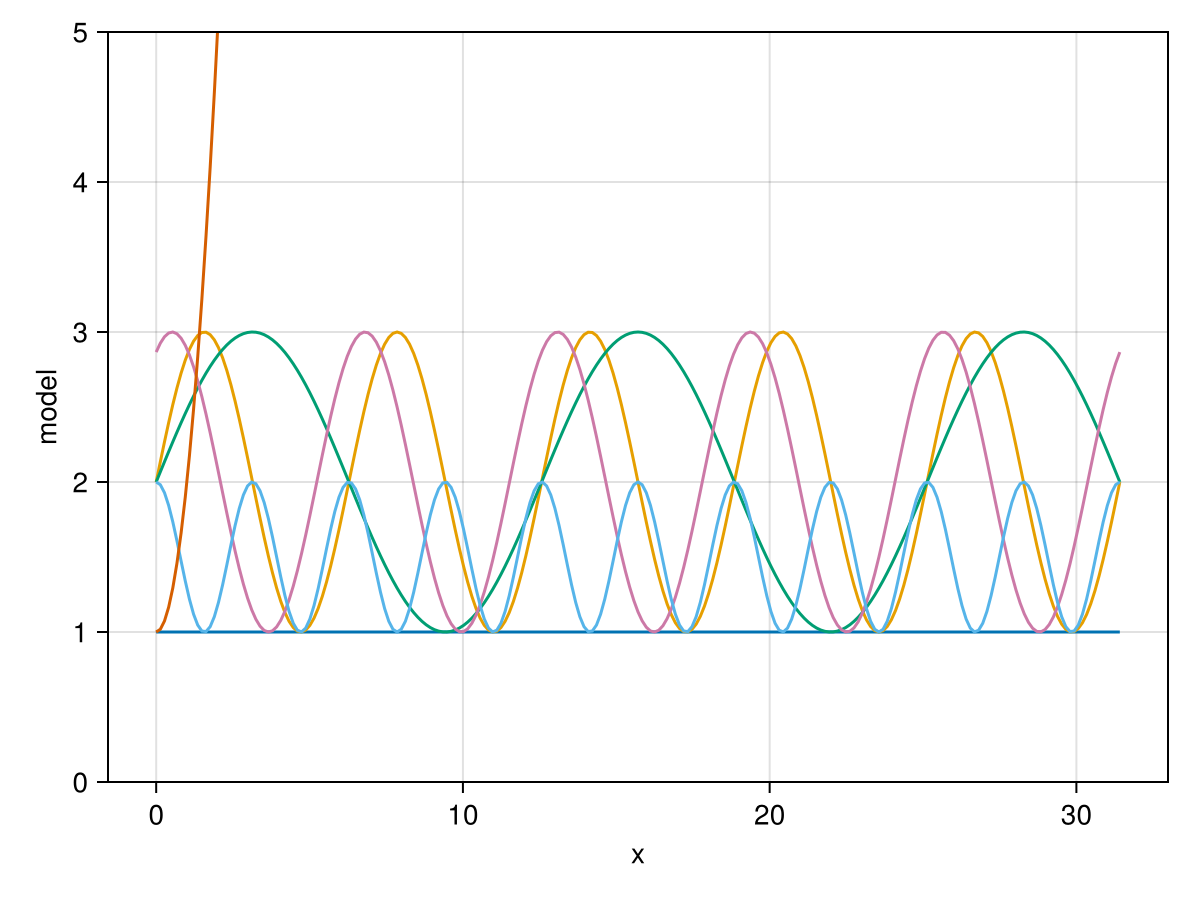

In [4]:
using Symbolics,CairoMakie,LinearAlgebra
CairoMakie.activate!()

logsOfHinverse = [0.5*i for i in 0:6] #[1.0*i for i in 0:4]

cases=[]
#prefix="B"*string(tmpOrderBspace)*"_"*"w"*string(tmpWorderBspace)*"_"*string(tmpSupplementaryOrder)*"_"
prefix=""
L = 10.0*π
@variables x
∂ = Differential(x)

cases = push!(cases,(name=prefix*"homogeneous",u=cos(x),β=1.0))
cases = push!(cases,(name=prefix*"sameλ",u=cos(x),β=sin(x)+2))
cases = push!(cases,(name=prefix*"twiceλ",u=cos(x),β=sin(x/2) + 2))
cases = push!(cases,(name=prefix*"sameλ_shifted_π_3",u=cos(x),β=sin(x+π/3) + 2))
cases = push!(cases,(name=prefix*"λ_2",u=cos(x),β=cos(x).^2 + 1))
cases = push!(cases,(name=prefix*"quadratic",u=cos(x),β=x^2+ 1))


misfit = Array{Float64,3}(undef,length(logsOfHinverse),length(cases),nConfigurations)


fig = Figure()
ax = Axis(fig[1, 1], xlabel="x", ylabel="model")
iH=5
for iCase ∈ eachindex(cases)
    name,_,β = cases[iCase]
    ΔxTry = exp(-logsOfHinverse[iH])
    Nx = Int(L÷ΔxTry) +1
    Δx = L/(Nx-1)
    X = [Δx * (i-1) for i ∈ range(1,Nx)]
    model=[Symbolics.value(substitute(β,Dict(x=>X[i]))) for i ∈ range(1,Nx)]
    lines!(ax, X, model)
end
ylims!(ax, 0, 5)
display(fig)
Nx=nothing
Δx=nothing
iH=nothing
modelFamily=Array{Any,3}(undef,length(logsOfHinverse),length(cases),nConfigurations)
forceFamily=Array{Any,3}(undef,length(logsOfHinverse),length(cases),nConfigurations)
for iConfigUsed ∈ eachindex(nameConfigs), iCase ∈ eachindex(cases), iH ∈ eachindex(logsOfHinverse)
    name,T,β = cases[iCase]
    iExperiment = (iH=iH,iCase=iCase,iPointsUsed=iConfigUsed)

    ΔxTry = exp(-logsOfHinverse[iH])
    Nx = Int(L÷ΔxTry) +1
    Δx = L/(Nx-1)
    X = [Δx * (i-1) for i ∈ range(1,Nx)]
    modelName = name*string(Nx)
    models=[]
    model=[Symbolics.value(substitute(β,Dict(x=>X[i]))) for i ∈ range(1,Nx)]
    models=push!(models, model)
    modelPoints = (Nx)
    
    
    q = mySimplify(β*∂(T))
    qₓ = mySimplify(∂(q))
    symbols=(Nx=Nx,Δx=Δx,X=X,q=q,qₓ=qₓ,T=T,β=β)
    
    tmpModel = (models=models, modelName=modelName, modelPoints=modelPoints,Δ=(Δx),symbols=symbols)
    modelFamily[iH,iCase,iConfigUsed]=tmpModel

    force = [Symbolics.value(substitute(qₓ,Dict(x=>X[i]))) for i ∈ range(1,Nx)]
    sourceFull=reshape(force,Nx,1,1)
    forceFamily[iH,iCase,iConfigUsed]=sourceFull
   
end


    

# input parameters

In [5]:

famousEquationType="1DpoissonHetero" 

"1DpoissonHetero"

In [ ]:
using JLD2, LinearAlgebra

checkpoint_file = "misfit_checkpoint_smaller.jld2"
figdir = joinpath(pwd(), "tmp", "figures")
mkpath(figdir)


if isfile(checkpoint_file)
    data = load(checkpoint_file)
    misfit = data["misfit"]
    done = data["done"]
else
    misfit = fill(NaN, length(logsOfHinverse), length(cases), nConfigurations)
    done = falses(length(logsOfHinverse), length(cases), nConfigurations)
end

for iConfigUsed in eachindex(nameConfigs), iCase in eachindex(cases), iH in eachindex(logsOfHinverse)
    if done[iH, iCase, iConfigUsed]
        continue
    end
    #if iH*iCase >1
    #    continue
    #end

    


    try
        name, T, β = cases[iCase]
        iExperiment = (iH=iH, iCase=iCase, iPointsUsed=iConfigUsed)

        @unpack Nx, Δx, X, q, qₓ, T, β = modelFamily[iH, iCase, iConfigUsed].symbols
        cfg = nameConfigs[iConfigUsed]
        configNameTmp=cfg.name
        @unpack orderBtime, orderBspace, pointsInSpace, pointsInTime, supplementaryOrder, fieldItpl, materItpl = cfg
        #@unpack orderBtime, orderBspace, pointsInSpace, pointsInTime, supplementaryOrder, fieldItpl, materItpl = all_Configcases[iConfigUsed]

        concreteParametersForOPTConstruction = @strdict famousEquationType Δ=modelFamily[iH,iCase,iConfigUsed].Δ orderBtime orderBspace pointsInSpace pointsInTime supplementaryOrder fieldItpl materItpl
        optRec = myProduceOrLoad(makeOPTsemiSymbolic, concreteParametersForOPTConstruction, "semiSymbolic")

        params = @strdict optRec=optRec modelFam=modelFamily[iExperiment.iH,iExperiment.iCase,iExperiment.iPointsUsed] absorbingBoundaries=nothing maskedRegionInSpace=nothing
        numOpt = numericalOperatorConstruction(params)

        numOps = numOpt["numOperators"]
        #prepared = prepareNumericalOperators(numOps)
        preparedLin = prepareLinearSystem(numOps)


        sourceFull = forceFamily[iExperiment.iH, iExperiment.iCase, iExperiment.iPointsUsed]        

        syntheticData = timeMarchingSchemeLinear(
            preparedLin,
            1,
            modelFamily[iExperiment.iH,iExperiment.iCase,iExperiment.iPointsUsed].Δ,
            modelFamily[iExperiment.iH,iExperiment.iCase,iExperiment.iPointsUsed].modelName;
            videoMode=false,
            sourceType="Explicit",
            sourceFull=sourceFull,
            iExperiment=iExperiment,
            boundaryConditionForced=true,
        )



        #syntheticData = timeMarchingSchemePrepared(
        #    prepared,
        #    1,
        #    modelFamily[iExperiment.iH,iExperiment.iCase,iExperiment.iPointsUsed].Δ,
        #    modelFamily[iExperiment.iH,iExperiment.iCase,iExperiment.iPointsUsed].modelName;
        #    videoMode=false,
        #    sourceType="Explicit",
        #    sourceFull=sourceFull,
        #    iExperiment=iExperiment,
        #    boundaryConditionForced=true,
        #)

        syntheticData = reduce(vcat, syntheticData)
        analyticalData = [Symbolics.value(substitute(T, Dict(x => X[i]))) for i in 1:Nx]

        misfit[iH, iCase, iConfigUsed] = norm(syntheticData - analyticalData) / Nx
        done[iH, iCase, iConfigUsed] = true

        fig = Figure()
        ax = Axis(
            fig[1, 1],
            title = "model=$(cases[iCase].name), $(configNameTmp)",
            xlabel = "x",
            ylabel = "solution",
        )
        lines!(ax, X, analyticalData, color=:blue, label="analytical")
        scatter!(ax, X, syntheticData, color=:red, marker=:circle, label="synthetic")
        axislegend(ax)

        figfile = joinpath(
            figdir,
            "cmp_iH$(iH)_iCase$(iCase)_iConfig$(iConfigUsed)_obs$(orderBspace)_obt$(orderBtime)_pts$(pointsInSpace)_supp$(supplementaryOrder).png",
        )
        save(figfile, fig)

        jldsave(checkpoint_file; misfit=misfit, done=done)

    catch err
        @warn "Failed at (iH=$iH, iCase=$iCase, iConfigUsed=$iConfigUsed)" exception=(err, catch_backtrace())
        jldsave(checkpoint_file; misfit=misfit, done=done)
    end
end

In [7]:
function inspect_rhs_at_row(sourceFull, X; row)
    force_vec = vec(sourceFull[:, 1, 1])
    println("row = ", row)
    println("x[row] = ", X[row])
    println("sourceFull[row] = ", force_vec[row])
    return force_vec[row]
end


function inspect_worst_residual_row(numOps, Texpr, force_vec, X;
    field_id=1,
    time_slot=1,
    sparse_output=false,
    boundaryConditionForced=false,
    leftValue=1.0,
    rightValue=1.0,
)
    preparedLin = prepareLinearSystem(numOps)

    knownField = copy(preparedLin.known_lhs_template)
    knownForce = copy(preparedLin.known_rhs_template)
    knownForce .= 0.0
    knownForce[:, field_id, time_slot] .= force_vec

    A, b = evaluateLinearSystem(preparedLin, knownField, knownForce; sparse_output=sparse_output)

    if boundaryConditionForced
        applyBoundaryConditionForced!(A, b; leftValue=leftValue, rightValue=rightValue)
    end

    u_exact = Float64[
        Symbolics.value(substitute(Texpr, Dict(x => xi))) for xi in X
    ]

    lhs = A * u_exact
    r = lhs .- b
    imax = argmax(abs.(r))

    arow = vec(A[imax, :])
    nz = findall(!iszero, arow)

    println("worst row = ", imax)
    println("x[worst] = ", X[imax])
    println("u_exact[worst] = ", u_exact[imax])
    println("lhs[worst] = ", lhs[imax])
    println("b[worst] = ", b[imax])
    println("residual[worst] = ", r[imax])
    println("nonzero columns = ", nz)
    println("coefficients = ", arow[nz])

    return (
        row = imax,
        x = X[imax],
        residual = r,
        lhs = lhs,
        b = b,
        A = A,
        nz = nz,
        coeffs = arow[nz],
        u_exact = u_exact,
    )
end


inspect_worst_residual_row (generic function with 1 method)

In [8]:
using SparseArrays
using LinearAlgebra


function check_discrete_residual_vs_h(modelFamily, forceFamily, cases, all_Configcases, iCase, iConfigUsed, logsOfHinverse)
    vals = NamedTuple[]

    for iH in eachindex(logsOfHinverse)
        name, T, β = cases[iCase]
        numOps = nothing

        iExperiment = (iH=iH, iCase=iCase, iPointsUsed=iConfigUsed)
        mf = modelFamily[iH, iCase, iConfigUsed]
        ff = forceFamily[iH, iCase, iConfigUsed]

        @unpack Nx, Δx, X = mf.symbols

        @unpack orderBtime, orderBspace, pointsInSpace, pointsInTime, supplementaryOrder, fieldItpl, materItpl = all_Configcases[iConfigUsed]
        concreteParametersForOPTConstruction = @strdict famousEquationType Δ=mf.Δ orderBtime orderBspace pointsInSpace pointsInTime supplementaryOrder fieldItpl materItpl
        optRec = myProduceOrLoad(makeOPTsemiSymbolic, concreteParametersForOPTConstruction, "semiSymbolic")
        params = @strdict optRec=optRec modelFam=mf absorbingBoundaries=nothing maskedRegionInSpace=nothing
        numOpt = numericalOperatorConstruction(params)
        numOps = numOpt["numOperators"]

        rescheck = check_discrete_residual(
            numOps,
            T,
            vec(ff[:, 1, 1]),
            X;
            sparse_output=false,
            boundaryConditionForced=false,
        )

        push!(vals, (
            iH=iH,
            Nx=Nx,
            Δx=Δx,
            maxabs=rescheck.plus.maxabs,
            l2mean=rescheck.plus.l2mean,
        ))
    end

    return vals
end

function compare_force_formula(X, force_vec)
    exact = @. -2 * cos(X) * (1 + sin(X))
    println("force first values     = ", force_vec[1:min(8,end)])
    println("explicit formula first = ", exact[1:min(8,end)])
    println("max force diff = ", maximum(abs.(force_vec .- exact)))
    return exact
end


function inspect_row_balance(numOps, Texpr, force_vec, X;
    row,
    field_id=1,
    time_slot=1,
    sparse_output=false,
    boundaryConditionForced=false,
    leftValue=1.0,
    rightValue=1.0,
)
    preparedLin = prepareLinearSystem(numOps)

    knownField = copy(preparedLin.known_lhs_template)
    knownForce = copy(preparedLin.known_rhs_template)
    knownForce .= 0.0
    knownForce[:, field_id, time_slot] .= force_vec

    A, b = evaluateLinearSystem(preparedLin, knownField, knownForce; sparse_output=sparse_output)

    if boundaryConditionForced
        applyBoundaryConditionForced!(A, b; leftValue=leftValue, rightValue=rightValue)
    end

    u_exact = Float64[
        Symbolics.value(substitute(Texpr, Dict(x => xi))) for xi in X
    ]

    lhs = A * u_exact
    r = lhs .- b

    println("row = ", row)
    println("x[row] = ", X[row])
    println("u_exact[row] = ", u_exact[row])
    println("lhs[row] = ", lhs[row])
    println("b[row] = ", b[row])
    println("residual[row] = ", r[row])

    return (
        A = A,
        b = b,
        u_exact = u_exact,
        lhs = lhs,
        residual = r,
        row = row,
    )
end

function inspect_sampled_model_and_force(modelFamily, forceFamily, cases, iH, iCase, iConfigUsed)
    name, T, β = cases[iCase]
    mf = modelFamily[iH, iCase, iConfigUsed]
    ff = forceFamily[iH, iCase, iConfigUsed]

    model = mf.models[1]
    force = vec(ff[:, 1, 1])

    println("case = ", name)
    println("β expr = ", β)
    println("model first values = ", model[1:min(8, end)])
    println("model extrema = ", extrema(model))
    println("force first values = ", force[1:min(8, end)])
    println("force extrema = ", extrema(force))

    return nothing
end

function inspect_linear_row(numOps, force_vec; row, field_id=1, time_slot=1, sparse_output=false,
    boundaryConditionForced=false, leftValue=1.0, rightValue=1.0)

    preparedLin = prepareLinearSystem(numOps)

    knownField = copy(preparedLin.known_lhs_template)
    knownForce = copy(preparedLin.known_rhs_template)
    knownForce .= 0.0
    knownForce[:, field_id, time_slot] .= force_vec

    A, b = evaluateLinearSystem(preparedLin, knownField, knownForce; sparse_output=sparse_output)

    if boundaryConditionForced
        applyBoundaryConditionForced!(A, b; leftValue=leftValue, rightValue=rightValue)
    end

    arow = vec(A[row, :])
    nz = findall(!iszero, arow)

    println("row = $row")
    println("b[row] = ", b[row])
    println("nonzero columns = ", nz)
    println("coefficients = ", arow[nz])

    return (
        A = A,
        b = b,
        row = row,
        nz = nz,
        coeffs = arow[nz],
        fullrow = arow,
    )
end
function inspect_middle_row(numOps, sourceFull; boundaryConditionForced=false)
    force_vec = vec(sourceFull[:, 1, 1])
    preparedLin = prepareLinearSystem(numOps)
    row = preparedLin.NpointsSpace ÷ 2

    return inspect_linear_row(
        numOps,
        force_vec;
        row=row,
        sparse_output=false,
        boundaryConditionForced=boundaryConditionForced,
    )
end

function compare_with_flux_stencil(modelFamily, cases, iH, iCase, iConfigUsed, rowinfo)
    mf = modelFamily[iH, iCase, iConfigUsed]
    @unpack Δx = mf.symbols
    beta = mf.models[1]

    i = rowinfo.row
    @assert 2 <= i <= length(beta)-1 "Need an interior row"

    βL = 0.5 * (beta[i-1] + beta[i])
    βR = 0.5 * (beta[i] + beta[i+1])

    expected = [
        βL / Δx^2,
        -(βL + βR) / Δx^2,
        βR / Δx^2,
    ]

    println("row = ", i)
    println("beta[i-1:i+1] = ", beta[i-1:i+1])
    println("expected flux stencil = ", expected)
    println("actual stencil        = ", rowinfo.coeffs)
    println("difference            = ", rowinfo.coeffs .- expected)

    return (
        row = i,
        beta_local = beta[i-1:i+1],
        expected = expected,
        actual = rowinfo.coeffs,
        difference = rowinfo.coeffs .- expected,
    )
end




compare_with_flux_stencil (generic function with 1 method)

In [9]:

vals = check_discrete_residual_vs_h(
    modelFamily,
    forceFamily,
    cases,
    all_Configcases,
    1,   # iCase
    1,   # iConfigUsed
    logsOfHinverse,
)



for v in vals
    @show v
end

UndefVarError: UndefVarError: `all_Configcases` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [10]:
using LinearAlgebra
using Symbolics


function applyBoundaryConditionForced!(A, b; leftValue=1.0, rightValue=1.0)
    A[1, :] .= 0
    A[1, 1] = 1
    b[1] = leftValue

    A[end, :] .= 0
    A[end, end] = 1
    b[end] = rightValue

    return A, b
end

function check_discrete_residual(numOps, Texpr, force_vec, X;
    field_id=1,
    time_slot=1,
    sparse_output=false,
    boundaryConditionForced=false,
    leftValue=1.0,
    rightValue=1.0,
)
    preparedLin = prepareLinearSystem(numOps)

    knownField = copy(preparedLin.known_lhs_template)
    knownForce = copy(preparedLin.known_rhs_template)

    u_exact = Float64[
        Symbolics.value(substitute(Texpr, Dict(x => xi))) for xi in X
    ]

    function one_check(force_sign)
        knownForce .= 0.0
        knownForce[:, field_id, time_slot] .= force_sign .* force_vec

        A, b = evaluateLinearSystem(preparedLin, knownField, knownForce; sparse_output=sparse_output)

        if boundaryConditionForced
            applyBoundaryConditionForced!(A, b; leftValue=leftValue, rightValue=rightValue)
        end

        r = A * u_exact .- b
        return (
            residual = r,
            maxabs = maximum(abs.(r)),
            l2mean = norm(r) / length(r),
            A = A,
            b = b,
            u_exact = u_exact,
        )
    end

    plus  = one_check(+1.0)
    minus = one_check(-1.0)

    println("force sign +1: maxabs = $(plus.maxabs), l2mean = $(plus.l2mean)")
    println("force sign -1: maxabs = $(minus.maxabs), l2mean = $(minus.l2mean)")

    better_sign = plus.l2mean <= minus.l2mean ? +1 : -1

    return (
        plus = plus,
        minus = minus,
        better_sign = better_sign,
    )
end


check_discrete_residual (generic function with 1 method)

In [11]:
sel = [
    c.orderBtime == 1 &&
    c.supplementaryOrder == 2
    for c in all_Configcases
]
misfit_sub = misfit[:, :, sel]
configs_sub = all_Configcases[sel]

UndefVarError: UndefVarError: `all_Configcases` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [13]:



@load fileMisfit misfit

@show misfit

fig =Figure()
for iPointsUsed in eachindex(numPointsX)
    ax=Axis(fig[1,iPointsUsed]; title="Misfit")
    N=length(cases)
    colors = [get(Makie.colorschemes[:viridis], (i - 1) / (N - 1)) for i in 1:N]
    for iCase in eachindex(cases)
        scatter!(ax,logsOfHinverse,log.(misfit[:,iCase,iPointsUsed]),color=colors[iCase],label=cases[iCase].name)
    end

    #O_1=log.(misfit[1,1,1]).-1.0*logsOfHinverse
    local O_2=log.(1.0).-2.0*logsOfHinverse
    local O_4=log.(1.0).-4.0*logsOfHinverse
    #O_8=log.(misfit[1,1,1]).-1.0*logsOfHinverse
    #lines!(ax,logsOfHinverse,O_1,color=:black,label="O1")
    lines!(ax,logsOfHinverse,O_2,color=:pink,label="O2")
    lines!(ax,logsOfHinverse,O_4,color=:pink,label="O4")
    #lines!(ax,logsOfHinverse,O_8,color=:black,label="O8")
    #axislegend(ax,position=:lb)
end
display(fig)

UndefVarError: UndefVarError: `fileMisfit` not defined in `Main`
Suggestion: check for spelling errors or missing imports.